# `size_to_pc`
Converts a size map (typically the output of a porosimetry simulation) into a capillary-pressure map using a user-supplied or default Washburn-style equation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import porespy as ps
from porespy.tools import get_edt

ps.visualization.set_mpl_style()

The arguments and their defaults are. Any extra keyword arguments are forwarded to `f`.

In [2]:
import inspect

inspect.signature(ps.filters.size_to_pc)

<Signature (im, size, f=None, **kwargs)>

## `im` and `size`
`im` is the boolean void mask, and `size` is a size map: each void voxel holds the radius (in voxels) at which it was invaded. Solid is encoded as 0 and any uninvaded voxels as -1.

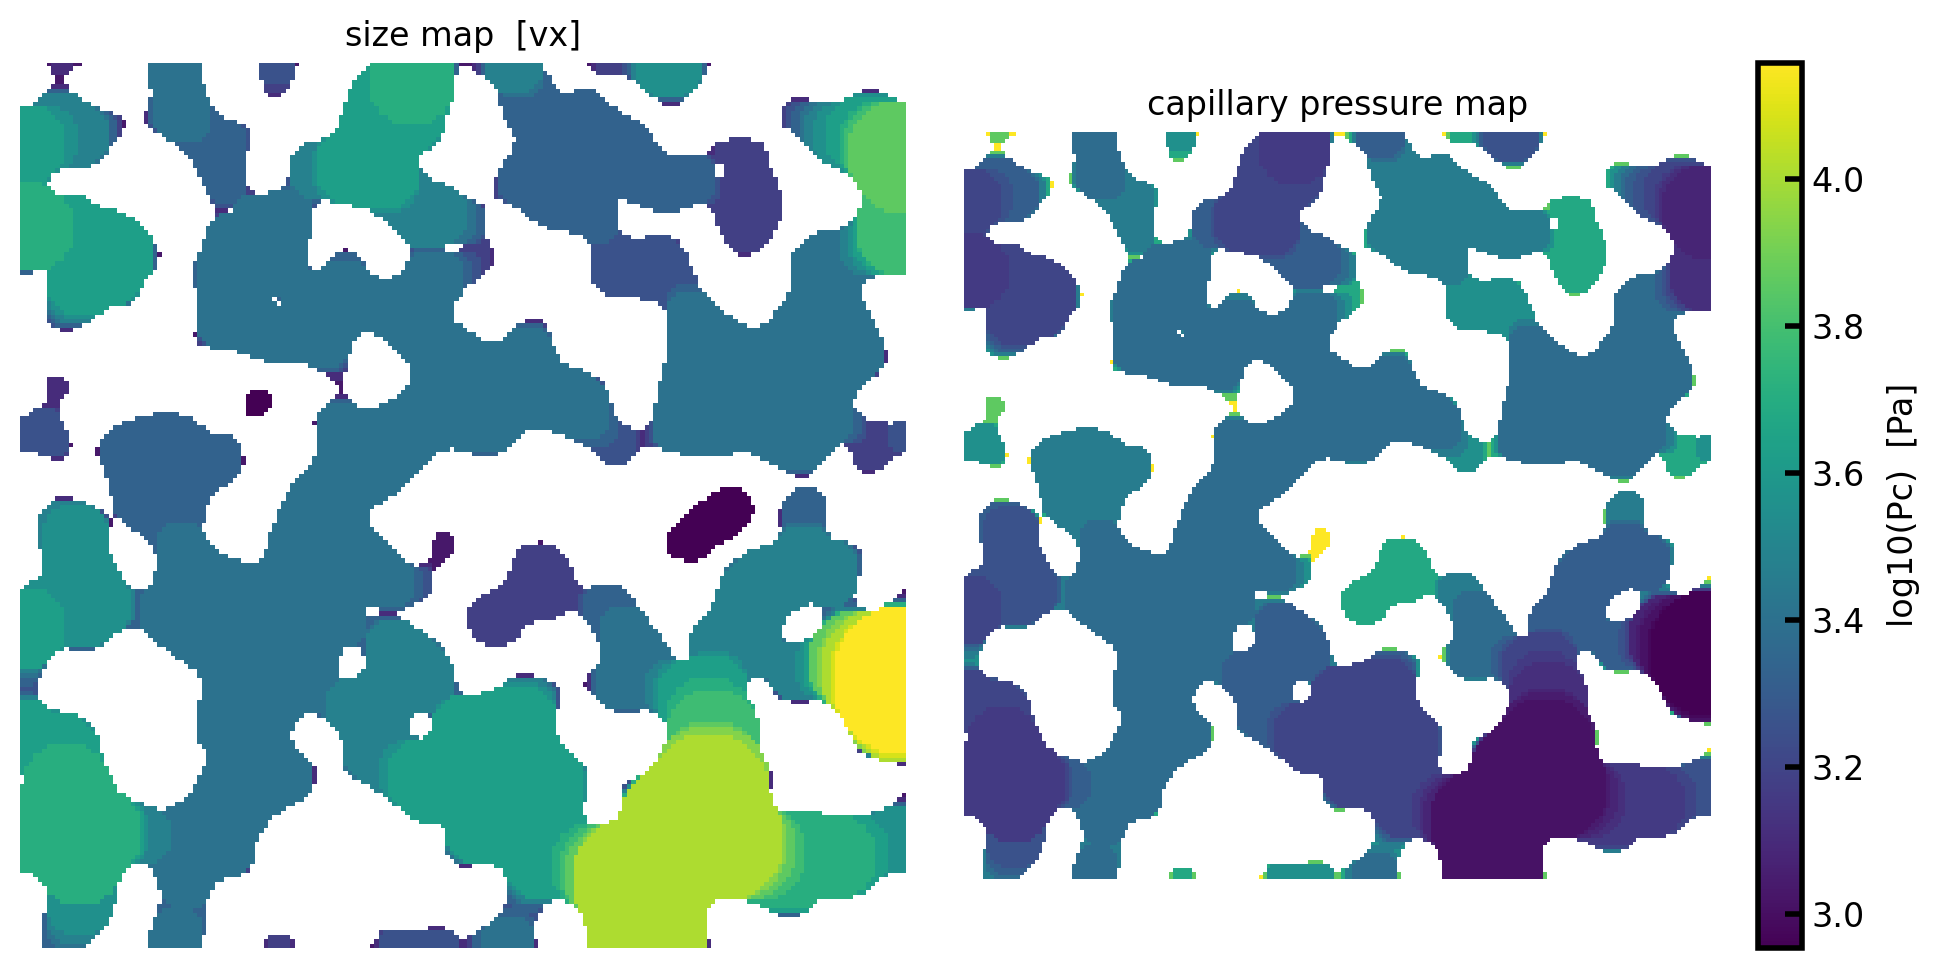

In [3]:
im = ps.generators.blobs(shape=[200, 200], porosity=0.6, seed=0)
size = ps.filters.porosimetry(im=im)

pc = ps.filters.size_to_pc(
    im=im, size=size, sigma=0.072, theta=180, voxel_size=1e-5)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(size / im, origin='lower', interpolation='none')
ax[0].set_title('size map  [vx]')
ax[0].axis(False)
h = ax[1].imshow(np.log10(pc) / im, origin='lower', interpolation='none')
fig.colorbar(h, ax=ax[1], label='log10(Pc)  [Pa]')
ax[1].set_title('capillary pressure map')
ax[1].axis(False);

## Default Washburn equation
If `f` is not supplied, the default is `Pc = -2 * sigma * cos(theta) / (r * voxel_size)`. So `sigma`, `theta` (in degrees), and `voxel_size` must be passed as keyword arguments. `theta` is measured through the non-wetting phase.

In [4]:
for vs in [1e-6, 1e-5, 1e-4]:
    pc = ps.filters.size_to_pc(
        im=im, size=size, sigma=0.072, theta=180, voxel_size=vs)
    print(f'voxel_size = {vs:.0e}  ->  median Pc = {np.median(pc[im]):.3e} Pa')

voxel_size = 1e-06  ->  median Pc = 2.400e+04 Pa
voxel_size = 1e-05  ->  median Pc = 2.400e+03 Pa
voxel_size = 1e-04  ->  median Pc = 2.400e+02 Pa


## `f`
Provide a custom relationship by passing a callable. It receives the size array as its first positional argument and any extra keyword arguments. This is convenient for non-Washburn correlations or for dimensionless conversions.

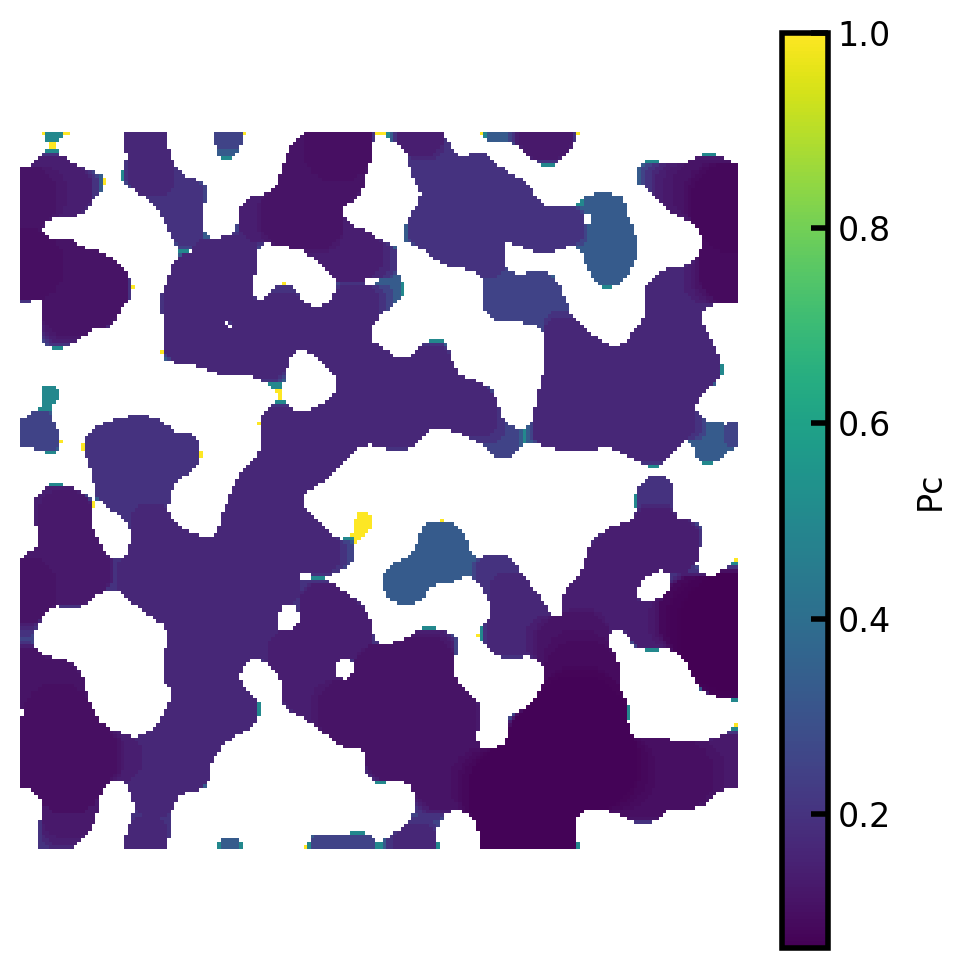

In [5]:
def my_pc(r, alpha):
    return alpha / r  # arbitrary inverse-radius law

pc = ps.filters.size_to_pc(im=im, size=size, f=my_pc, alpha=1.0)

fig, ax = plt.subplots(figsize=[5, 5])
h = ax.imshow(pc / im, origin='lower', interpolation='none')
fig.colorbar(h, ax=ax, label='Pc')
ax.axis(False);